# Example 3: Ruin Probability with Log-normal Claims
Here we consider a risk model with log-normal claim amounts.
The Laplace transform of a log-normal density has no known closed form, so we need approximations.


In [6]:
import sys
import os

# Add the parent directory to sys.path so we can import our src modules
sys.path.append(os.path.abspath('../'))

import mpmath, matplotlib.pyplot as plt
from tqdm import tqdm # for measuring progress

from src.talbot import talbot_method_abate
from src.laplace_transforms import lapl_psi, lapl_psi_1, lapl_psi_2, lapl_LN
from src.utils import print_results, talbot_zeroes, talbot_zeroes_path

In [7]:
# Set global precision
M = 60
ctx = mpmath.mp
ctx.dps = M

## Parameter Setup

In [8]:
mu_ln = ctx.mpf('1')    # mean of the normal
sigma_ln = ctx.mpf('1') # sd of the normal

mu = ctx.exp(mu_ln + sigma_ln**2 / 2)
c = ctx.mpf('2')
sigmasq = ctx.mpf('0.4')
lmbda = ctx.mpf('0.25')
# Other values
q = (c - lmbda * mu)/c
zeta = 2 * c / sigmasq

print(q > 0)

True


## Verification of (B1)
Assumption **(B1)** from the thesis is not obvious and verifying it analytically hard.
So we use a numerical version of the argument principle.

7496


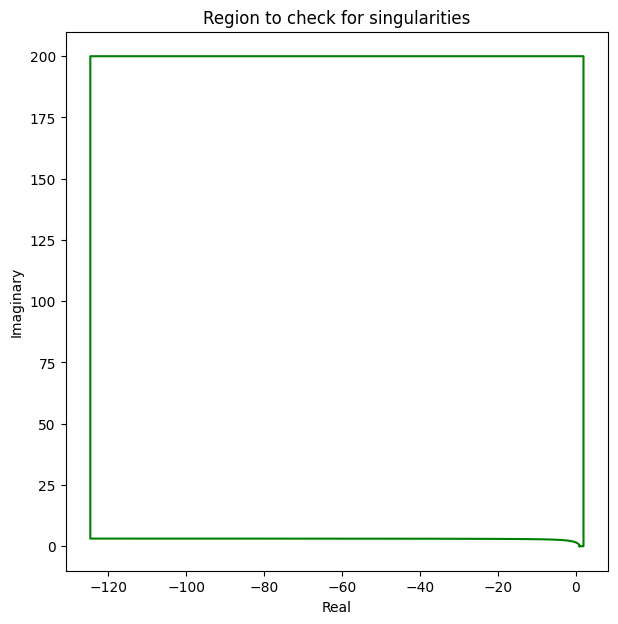

In [9]:
eps, Im_max, N_talbot, linear_rate = 0.025, 200, 1e3, 10

z_values = talbot_zeroes_path(ctx, eps, Im_max=Im_max, N_talbot=N_talbot, linear_rate=linear_rate)
print(len(z_values))

plt.figure(figsize=(7, 7))
plt.plot([z.real for z in z_values], [z.imag for z in z_values], 'g-')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Region to check for singularities")
plt.show()

In [10]:
n = talbot_zeroes(lapl_LN, c, zeta, lmbda, 100, eps,
                  Im_max=Im_max, N_talbot=N_talbot, linear_rate=linear_rate,
                  mu_N=mu_ln, sigma_N=sigma_ln) # Parameters of claim density

Evaluating D(z) along the closed bounding contour...


100%|██████████| 7496/7496 [30:42<00:00,  4.07it/s]


Calculating and unwrapping phase...


In [11]:
print(n)

0.0


## Compute Probabilities

In [ ]:
u_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 10, 20]

approx = [talbot_method_abate(lapl_psi, u, M,
                              lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln) for u in tqdm(u_values)]

approx_oscillation = [talbot_method_abate(lapl_psi_1, u, M,
                                          lmbda=lmbda,
                                          c=c,
                                          sigmasq=sigmasq,
                                          lapl_X_func=lapl_LN,
                                          mu_N=mu_ln,
                                          sigma_N=sigma_ln) for u in tqdm(u_values)]

approx_claim = [talbot_method_abate(lapl_psi_2, u, M,
                                    lmbda=lmbda,
                                    mu=mu,
                                    c=c,
                                    sigmasq=sigmasq,
                                    lapl_X_func=lapl_LN,
                                    mu_N=mu_ln,
                                    sigma_N=sigma_ln) for u in tqdm(u_values)]

100%|██████████| 12/12 [01:28<00:00,  7.40s/it]


## Display Results

In [ ]:
print_results([u_values, approx, approx_oscillation, approx_claim],
              header="u\tApprox\t\tApprox (osc)\tApprox (claim)", num_digits=8)

u	Approx		Approx (osc)	Approx (claim)
0.1	0.72143034	0.37118594	0.35024439
0.2	0.61674776	0.14278848	0.47395928
0.3	0.57521322	0.05986819	0.51534503
0.4	0.55659996	0.029776834	0.52682312
0.5	0.54630603	0.018846967	0.52745906
1.0	0.51624497	0.012203463	0.50404151
2.0	0.46648468	0.010434432	0.45605025
3.0	0.42407972	0.0089090994	0.41517062
4.0	0.38763742	0.0077117188	0.3799257
5.0	0.35588773	0.0067616401	0.34912609
10.0	0.24235189	0.0039489978	0.23840289
20.0	0.12576221	0.0017429699	0.12401924


In [ ]:
app_mix = [app1 + app2 for app1, app2 in zip(approx_oscillation, approx_claim)]
print_results([u_values, approx, app_mix], header="Checking that mix and direct yield similar results")

Checking that mix and direct yield similar results
0.1	0.7214303357	0.7214303357
0.2	0.6167477609	0.6167477609
0.3	0.5752132227	0.5752132227
0.4	0.5565999589	0.5565999589
0.5	0.5463060291	0.5463060291
1.0	0.5162449735	0.5162449735
2.0	0.4664846841	0.4664846841
3.0	0.4240797191	0.4240797191
4.0	0.3876374199	0.3876374199
5.0	0.3558877279	0.3558877279
10.0	0.2423518878	0.2423518878
20.0	0.1257622052	0.1257622052


## Justification for choise of $\alpha$ and cutoff

$\alpha$ governs the error in the approximation of $\mathcal{L}(f_X)$.
We choose $\alpha = 15$ to get approximately $\mathrm{e}^{-15} \approx 10^{-7}$.
The cut-off index has to be chosen large enough, such as to capture enough information to get an accurate approximation. To this end, we consider the convergence of the approximation of $\mathcal{L}(\psi)(r)$, which is the most important term.

100%|██████████| 80/80 [00:01<00:00, 73.84it/s]


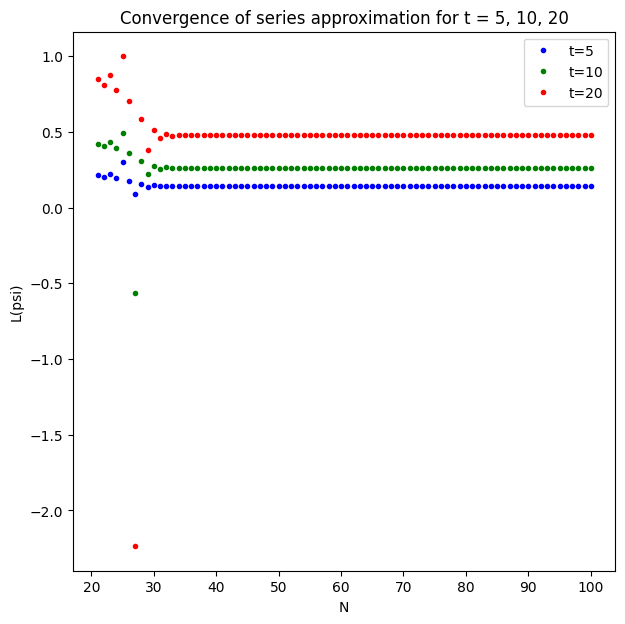

In [ ]:
t = 10
r = ctx.fraction('2', '5') * M / t

# Consider cutoffs from 21 to 101
Ns = range(21, 101)
lapl_psi_values_10 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

t = 5
r = ctx.fraction('2', '5') * M / t
lapl_psi_values_5 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

t = 20
r = ctx.fraction('2', '5') * M / t
lapl_psi_values_20 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

plt.figure(figsize=(7, 7))
plt.plot(Ns, [z.real for z in lapl_psi_values_5], 'b.', label="t=5")
plt.plot(Ns, [z.real for z in lapl_psi_values_10], 'g.', label="t=10")
plt.plot(Ns, [z.real for z in lapl_psi_values_20], 'r.', label="t=20")
plt.xlabel("N")
plt.ylabel("L(psi)")
plt.title("Convergence of series approximation for t = 5, 10, 20")
plt.legend()
plt.savefig("evolution_in_n.png")

In [ ]:
t = 10
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=15, maxSum=70), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=20, maxSum=80), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=25, maxSum=90), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=30, maxSum=100), 15))

0.242351887823488
0.24235188782023
0.242351887820246
0.242351887820246
